In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.datasets import make_classification
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold, train_test_split

sys.path.append('src')
plt.style.use('ggplot')

from utils import bootstrap_mcfadden_r2

# Model Evaluation

By now we have built models, reduced predictors and transformed variables. At some point we have to ask a simple question: how good is the model really? When the goal is prediction performance we often need to compare different models. We cannot naively trust the measures we get from the training dataset, since there is always a risk of overfitting. In this notebook, we will see different ways to evaluate model performance.


## Data Splitting

Data splitting is perhaps the most common way to evaluate model performance. Indeed, it has several benefits:

* Splitting into train and test sets allows us to get approximately unbiased estimates of model performance.
* We can detect overfitting by comparing training and test set performance.
* We can experiment with the training dataset,  while reserving the test set for an honest evaluation of performance.

However, it has a couple of downsides as well:

* When we do data splitting, we only evaluate model performance using a single split of the data. The improved performance could be solely due to chance, and the results can be misleading.
* Both training and testing are suboptimal since we sacrifice data points in each step.
* We need a relatively large dataset to apply data splitting. To get reliable performance results, at least 100 data points are required. For classification tasks, at least 100 data points should belong to the minority class.
* The final model will be fit on the whole dataset, which is not validated.

**Example**

$n=1000$

$x_1 \sim \mathcal{N}(5,1)$

$x_2 \sim \mathcal{N}(3,1)$

$x_3 \sim \mathcal{N}(7,\ 2^2)$

$\varepsilon \sim \mathcal{N}(0,1)$

$y = 2x_1 + 1.5x_2 + 0.5x_3 + \varepsilon$


In [2]:
np.random.seed(42)
n = 1000
x1 = np.random.normal(5, 1, n)
x2 = np.random.normal(3, 1, n)
x3 = np.random.normal(7, 2, n)
error = np.random.normal(0, 1, n)

X = np.column_stack([x1, x2, x3])
y = 2*x1 + 1.5*x2 + 0.5*x3 + error

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
model = sm.OLS(y_train, sm.add_constant(X_train)).fit()
model_pred = model.predict(sm.add_constant(X_test))
r2_test = r2_score(y_test, model_pred)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.864
Model:                            OLS   Adj. R-squared:                  0.863
Method:                 Least Squares   F-statistic:                     1685.
Date:                Tue, 11 Aug 2026   Prob (F-statistic):               0.00
Time:                        14:24:01   Log-Likelihood:                -1153.5
No. Observations:                 800   AIC:                             2315.
Df Residuals:                     796   BIC:                             2334.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0532      0.259      0.206      0.8

In [4]:
print(f"Train R²: {model.rsquared:.4f}")
print(f"Test R²: {r2_test:.4f}")

Train R²: 0.8640
Test R²: 0.8623


## Cross Validation

The idea is to split the data into different configurations (k times) and iteratively evaluate model performance on each. K-fold cross validation generally works better than leave one out cross-validation (LOOCV), since the k models fit under LOOCV are nearly identical to one another, which inflates the variance of the resulting performance estimate.

This approach is preferable to a single train/test split unless the dataset is very large, since it makes better use of the available data and produces a more stable performance estimate through repeated evaluation. However, it is still not optimal. The final model is refit on the whole dataset, and this final model's performance is never directly validated.

In [5]:
for i,(train_idx,test_idx) in enumerate(KFold(n_splits = 5).split(X)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = sm.OLS(y_train, sm.add_constant(X_train)).fit()
    model_pred = model.predict(sm.add_constant(X_test))

    r2_test = r2_score(y_test, model_pred)
    print("Fold:", i+1)
    print("Train R²:", model.rsquared)
    print(f"Test R²: {r2_test:.4f}")
    print()

Fold: 1
Train R²: 0.8639623538498307
Test R²: 0.8617

Fold: 2
Train R²: 0.8662745804350074
Test R²: 0.8545

Fold: 3
Train R²: 0.8696448815648589
Test R²: 0.8386

Fold: 4
Train R²: 0.8594462711387578
Test R²: 0.8821

Fold: 5
Train R²: 0.8618472052450916
Test R²: 0.8721



## Resampling

Resampling methods such as the bootstrap and the jackknife allow us to obtain almost unbiased estimates of model performance without sacrificing any data points. Efron showed that using the bootstrap for model evaluation is roughly equivalent to having an independent test set with double the number of data points of the original dataset.

### The Bootstrap Approach

In the original bootstrap evaluation approach, the following steps were used:

For $B$ bootstrap samples:
* Sample $n$ times with replacement from the dataset, which has $n$ data points.
* Fit a model on the bootstrap sample. Record the model's performance on the original dataset.

Average the recorded performance across all $B$ bootstrap samples.


In [6]:
np.random.seed(42)
n = 1000
x1 = np.random.normal(5, 1, n)
x2 = np.random.normal(3, 1, n)
x3 = np.random.normal(7, 2, n)
error = np.random.normal(0, 1, n)

X = np.column_stack([x1, x2, x3])
y = 2*x1 + 1.5*x2 + 0.5*x3 + error

data = pd.DataFrame({'x1': x1, 'x2': x2, 'x3': x3, 'y': y})

B = 200
r2_scores = []
for _ in range(B):
    bootstrapped_sample = data.sample(n=n, replace=True)
    X_boot = sm.add_constant(bootstrapped_sample[['x1', 'x2', 'x3']])
    y_boot = bootstrapped_sample['y']
    model = sm.OLS(y_boot, X_boot).fit()
    pred = model.predict(sm.add_constant(X))
    score = r2_score(y, pred)
    r2_scores.append(score)

avg_r2 = np.mean(r2_scores)
print(f"Average R²: {avg_r2:.4f}")


Average R²: 0.8636


However, this approach has a downside. When we sample $n$ points with replacement from a dataset of $n$ points, each original data point has about a 63.2% chance of showing up at least once in the bootstrap sample. This means most of the data used to evaluate the model was also used to train it. As a result, the performance estimate tends to be too optimistic.

However, this optimism can be corrected. The "Optimism Corrected Bootstrap" method does exactly that.

### The Optimism-Corrected Bootstrap Approach

The idea is straightforward. We first fit the model on the entire original dataset and record its apparent performance, evaluated on that same dataset. Then, for each bootstrap sample, we estimate the optimism introduced by the traditional bootstrap approach:

$\text{Optimism} = \text{performance on bootstrap sample} - \text{performance on original dataset}$

Here, both performances come from the model fit on the bootstrap sample, one evaluated on the bootstrap sample itself, the other on the original dataset.

Finally, we subtract the average optimism (across all bootstrap samples) from the apparent performance we obtained in the first step.

#### Comparing Two Linear Regression Models

Let's compare a simple model (1 predictor) against a full model (3 predictors). We will use $R^2$ as the evaluation metric since OLS is already optimized for squared error loss and comparing models in that domain can be misleading.

In [7]:
np.random.seed(42)
n = 200
x1 = np.random.normal(5, 1, n)
x2 = np.random.normal(3, 1, n)
x3 = np.random.normal(7, 2, n)
error = np.random.normal(0, 1, n)
y = 2*x1 + 1.5*x2 + 0.5*x3 + error

X_A = sm.add_constant(x1)
X_B = sm.add_constant(np.column_stack([x1, x2, x3]))

model_A_orig = sm.OLS(y, X_A).fit()
model_B_orig = sm.OLS(y, X_B).fit()

apparent_r2_A = r2_score(y, model_A_orig.predict(X_A))
apparent_r2_B = r2_score(y, model_B_orig.predict(X_B))

print(f'Apparent R2 Model A (simple): {apparent_r2_A:.3f}')
print(f'Apparent R2 Model B (full):   {apparent_r2_B:.3f}')

Apparent R2 Model A (simple): 0.482
Apparent R2 Model B (full):   0.870


Model B has higher "apparent" $R^2$. But this is measured on the same data used for fitting so it's biased by overfitting. Let's estimate the optimism for each model.

In [8]:
n_bootstrap = 200
np.random.seed(42)

optimism_A = []
optimism_B = []

for _ in range(n_bootstrap):

    idx = np.random.choice(n, size=n, replace=True)
    y_boot = y[idx]
    X_A_boot = sm.add_constant(x1[idx])
    X_B_boot = sm.add_constant(np.column_stack([x1, x2, x3])[idx])

    model_A_boot = sm.OLS(y_boot, X_A_boot).fit()
    model_B_boot = sm.OLS(y_boot, X_B_boot).fit()

    r2_A_boot_train = r2_score(y_boot, model_A_boot.predict(X_A_boot))
    r2_A_boot_orig = r2_score(y, model_A_boot.predict(X_A))
    optimism_A.append(r2_A_boot_train - r2_A_boot_orig)

    r2_B_boot_train = r2_score(y_boot, model_B_boot.predict(X_B_boot))
    r2_B_boot_orig = r2_score(y, model_B_boot.predict(X_B))
    optimism_B.append(r2_B_boot_train - r2_B_boot_orig)

avg_optimism_A = np.mean(optimism_A)
avg_optimism_B = np.mean(optimism_B)

print(f'Average optimism Model A: {avg_optimism_A:.4f}')
print(f'Average optimism Model B: {avg_optimism_B:.4f}')

Average optimism Model A: 0.0007
Average optimism Model B: 0.0024


In [9]:
corrected_r2_A = apparent_r2_A - avg_optimism_A
corrected_r2_B = apparent_r2_B - avg_optimism_B

print(f'Corrected R2 Model A: {corrected_r2_A:.3f}')
print(f'Corrected R2 Model B: {corrected_r2_B:.3f}')
print(f'Difference (B - A):   {corrected_r2_B - corrected_r2_A:.3f}')

Corrected R2 Model A: 0.481
Corrected R2 Model B: 0.868
Difference (B - A):   0.386


Even after correcting for optimism, Model B still has a substantially higher $R^2$. The full model explains the data better. Therefore we can conclude that the apparent advantage was not simply due to overfitting.

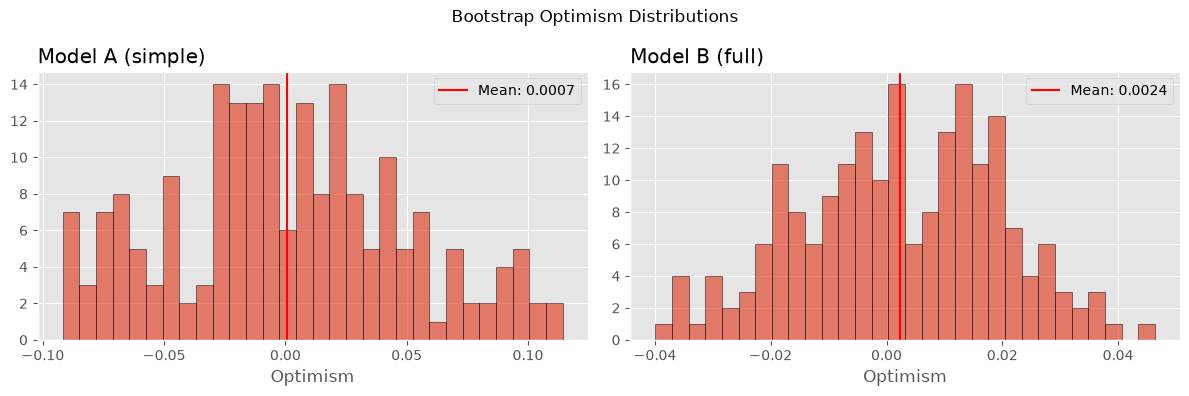

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(optimism_A, bins=30, edgecolor='black', alpha=0.7)
ax[0].axvline(x=avg_optimism_A, color='red', linestyle='-', label=f'Mean: {avg_optimism_A:.4f}')
ax[0].set_xlabel('Optimism')
ax[0].set_title('Model A (simple)', loc='left')
ax[0].legend()

ax[1].hist(optimism_B, bins=30, edgecolor='black', alpha=0.7)
ax[1].axvline(x=avg_optimism_B, color='red', linestyle='-', label=f'Mean: {avg_optimism_B:.4f}')
ax[1].set_xlabel('Optimism')
ax[1].set_title('Model B (full)', loc='left')
ax[1].legend()

fig.suptitle('Bootstrap Optimism Distributions')
plt.tight_layout()
plt.show()

## Comparing Two Logistic Regression Models

Accuracy is not the best way to evaluate classification models. It only captures a single threshold and it could be misleading when the dataset is imbalanced. Other traditional ML comparison metrics are also insufficient:

* F1, Precision and Recall evaluate model *labels* rather than probabilities.
* ROC-AUC comparison is better but it is not sensitive enough when both compared models are well performing. Also it measures ranking and using rank-based metrics is not recommended for logistic model comparison. ([Link](https://www.amazon.com/Regression-Modeling-Strategies-Applications-Statistics/dp/0387952322))

In likelihood-based models (like logistic regression), we should consider:

1. **Likelihood Ratio $\chi^2$**: Measures how much predictive information the model captures compared to a null model.

The idea is: how much more likely is the observed data under our fitted model vs. a model with no predictors? Formally it is denoted as:

 $LR\ \chi^2 = -2\ln\left(\frac{L_0}{L_1}\right) = -2(LL_0 - LL_1)$

where $LL_0$ is the null model log likelihood and $LL_1$ is the fitted model log likelihood. A larger value means the model captures more information.

2. **AIC**: Penalizes log-likelihood for model complexity:

$AIC = -2LL + 2p$

where  $p$ refers to number of parameters. The lower the AIC, the better. It should be evaluated alongside the likelihood ratio.

3. **Pseudo $R^2$ (McFadden)**: A log likelihood ratio based index scaled between 0 and 1. Defined as:

$\text{Pseudo }R^2 = 1 - LL_1/LL_0$


Let's implement this step by step.

In [11]:
np.random.seed(42)
X, y_cls = make_classification(n_samples=500, n_features=3,
                               n_informative=3, n_redundant=0,
                               random_state=42)

# Model A: reduced (2 features)
X_A = sm.add_constant(X[:, :2])
model_A = sm.Logit(y_cls, X_A).fit(disp=0)

# Model B: full (5 features)
X_B = sm.add_constant(X)
model_B = sm.Logit(y_cls, X_B).fit(disp=0)

print("Model A (reduced):")
print(model_A.summary())

Model A (reduced):
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  500
Model:                          Logit   Df Residuals:                      497
Method:                           MLE   Df Model:                            2
Date:                Tue, 11 Aug 2026   Pseudo R-squ.:                  0.5703
Time:                        14:24:02   Log-Likelihood:                -148.92
converged:                       True   LL-Null:                       -346.57
Covariance Type:            nonrobust   LLR p-value:                 1.446e-86
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2853      0.156      1.830      0.067      -0.020       0.591
x1             2.5841      0.234     11.066      0.000       2.126       3.042
x2             0.4056      0.122 

In [12]:
print("\nModel B (full):")
print(model_B.summary())


Model B (full):
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  500
Model:                          Logit   Df Residuals:                      496
Method:                           MLE   Df Model:                            3
Date:                Tue, 11 Aug 2026   Pseudo R-squ.:                  0.5820
Time:                        14:24:02   Log-Likelihood:                -144.88
converged:                       True   LL-Null:                       -346.57
Covariance Type:            nonrobust   LLR p-value:                 4.113e-87
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2128      0.163      1.304      0.192      -0.107       0.532
x1             2.3768      0.233     10.186      0.000       1.919       2.834
x2             0.3739      0.122   

From the LLR p-values, we understand that both models are better than the intercept only model. Model B has a higher log likelihood. However, it is also more complex. For a fair comparison we should look at AIC instead.


In [13]:
print("Model A AIC:", model_A.aic)
print("Model B AIC:", model_B.aic)

Model A AIC: 303.831847852329
Model B AIC: 297.7645651122164


Model B has a lower AIC score. Hence we can conclude that Model B is better than Model A.

### Optimism-Corrected Bootstrap Approach

Now let's apply the same optimism correction we used for linear regression, but this time with Pseudo $R^2$ as the performance metric. The logic is the same:

* Fit the model on a bootstrap sample.
* Measure optimism (bootstrap performance - original sample performance).
* Subtract average optimism from apparent performance.


In [14]:
model_A = sm.Logit(y_cls, X_A).fit(disp=0)
model_B = sm.Logit(y_cls, X_B).fit(disp=0)

r2m_A = model_A.prsquared
r2m_B = model_B.prsquared

In [15]:
n_boot = 200
n = len(y_cls)

optimism_A = np.zeros(n_boot)
optimism_B = np.zeros(n_boot)

for i in range(n_boot):
    idx = np.random.choice(n, size=n, replace=True)
    y_boot = y_cls[idx]

    # Model A
    model_boot_A = sm.Logit(y_boot, X_A[idx]).fit(disp=0)
    boot_r2_A = model_boot_A.prsquared 
    orig_r2_A = bootstrap_mcfadden_r2(X_A, y_cls, model_boot_A.predict)
    optimism_A[i] = boot_r2_A - orig_r2_A

    # Model B
    model_boot_B = sm.Logit(y_boot, X_B[idx]).fit(disp=0)
    boot_r2_B = model_boot_B.prsquared
    orig_r2_B = bootstrap_mcfadden_r2(X_B, y_cls, model_boot_B.predict)
    optimism_B[i] = boot_r2_B - orig_r2_B

avg_optimism_A = np.mean(optimism_A)
avg_optimism_B = np.mean(optimism_B)

print(f'Average optimism Model A (McFadden): {avg_optimism_A:.4f}')
print(f'Average optimism Model B (McFadden): {avg_optimism_B:.4f}')

Average optimism Model A (McFadden): 0.0052
Average optimism Model B (McFadden): 0.0073


In [16]:
corrected_r2_A = r2m_A - avg_optimism_A
corrected_r2_B = r2m_B - avg_optimism_B

print(f"{'Metric':<30} {'Model A':<12} {'Model B':<12}")
print("-" * 54)
print(f"{'Apparent McFadden R2':<30} {r2m_A:<12.3f} {r2m_B:<12.3f}")
print(f"{'Avg Optimism':<30} {avg_optimism_A:<12.4f} {avg_optimism_B:<12.4f}")
print(f"{'Corrected McFadden R2':<30} {corrected_r2_A:<12.3f} {corrected_r2_B:<12.3f}")

Metric                         Model A      Model B     
------------------------------------------------------
Apparent McFadden R2           0.570        0.582       
Avg Optimism                   0.0052       0.0073      
Corrected McFadden R2          0.565        0.575       


Model B has higher Pseudo $R^2$ even after optimism correction, and the LR test confirmed its additional predictors are statistically significant. Note that Model B also has higher optimism (more complex models always overfit more) but the correction accounts for this.

These tools let us judge a model honestly, correcting for the optimism that always creeps in when we evaluate on the same data we fit on.

Until this point we have seen various statistical applications. All of them rely solely on the data itself. This may not be sufficient in all cases. From now on, we will try to overcome the vulnerabilities of the frequentist view by introducing our beliefs into our statistical models. In other words, we will continue with Bayesian Statistics.
